# Gender signal of occupations in Dolci-SFT data

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Path config
root_dir = Path.cwd().parent.parent
data_dir = root_dir / "data" / "dolci"
signal_file = data_dir / "dolci_mnli_gender_classification.jsonl"

df = pd.read_json(signal_file, lines=True)
df.head()

,id,occupation,classification,score
0,3215,accountant,female,0.929688
1,6406,accountant,female,0.554688
2,6918,accountant,male,0.925781
3,12623,accountant,male,0.546875
4,12971,accountant,male,0.578125


In [11]:
original_len = len(df)
original_len

1019832

In [12]:
# filter df to include critical occcupations
occupations_of_interest = [
            "carpenter", 
            "mechanic", 
            "engineer", 
            "scientist", 
            "professor", 
            "doctor", 
            "teacher", 
            "nurse",
            "secretary",
            "programmer", 
            "politician", 
            "artist", 
            "author", 
    ]

df = df[df["occupation"].isin(occupations_of_interest)]
print(f"Remaining len: {len(df)} ({len(df) / original_len:.2%})")

Remaining len: 196498 (19.27%)


## Gender breakdown for each occupation

Histogram plot showing all occupations on x axis, and the count of male and female per occupation.

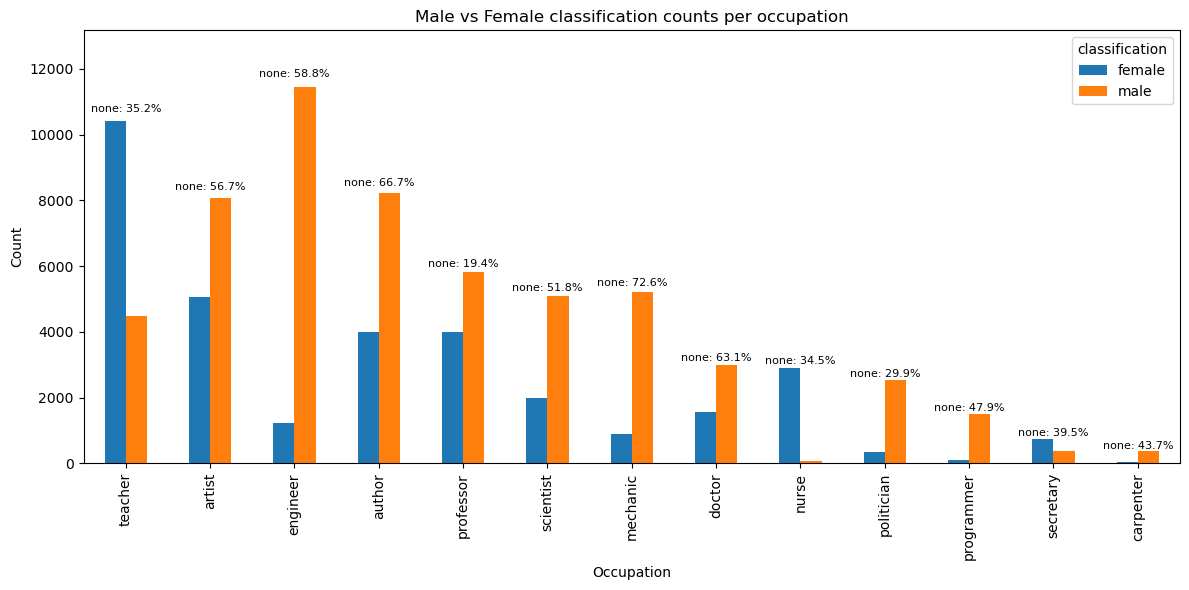

In [15]:
# compute counts of male/female per occupation and plot
counts = (
    df[df['classification'].isin(['male', 'female'])]
    .groupby(['occupation', 'classification'])
    .size()
    .unstack(fill_value=0)
)

# sort by total frequency (optional)
counts['total'] = counts.sum(axis=1)
counts = counts.sort_values('total', ascending=False).drop(columns='total')

# compute none percentage per occupation
totals = df.groupby('occupation').size()
none_counts = df[df['classification'] == 'none'].groupby('occupation').size()
none_pct = (none_counts / totals).reindex(counts.index).fillna(0)

# plot
ax = counts.plot(kind='bar', figsize=(12, 6))
ax.set_xlabel('Occupation')
ax.set_ylabel('Count')
ax.set_title('Male vs Female classification counts per occupation')
plt.xticks(rotation=90)

# annotate none percentage above each occupation group
max_counts = counts.max(axis=1)
y_max = max_counts.max()
for x, occ in zip(ax.get_xticks(), counts.index):
    y = max_counts.loc[occ]
    offset = max(1, y * 0.02)
    ax.text(x, y + offset, f"none: {none_pct.loc[occ]:.1%}", ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, max(1, y_max * 1.15 + 1))

plt.tight_layout()
plt.show()